In [ ]:
from google.colab import files
uploaded= files.upload()

Saving spam.csv to spam (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print(df.shape)
df.head()


(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
df.rename(columns={'v1':'label','v2':'message'},inplace=True)
df.head()
print(df.shape)

(5572, 5)


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.head()


,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df = df[['label', 'message']]
df.shape

(5169, 2)

In [ ]:
df.dropna(inplace=True)
print(df.shape)

(5169, 2)


In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [ ]:
df['label'].value_counts()

,count
label,
0,4516
1,653


In [ ]:
df.shape

(5169, 2)

<Axes: xlabel='label', ylabel='count'>

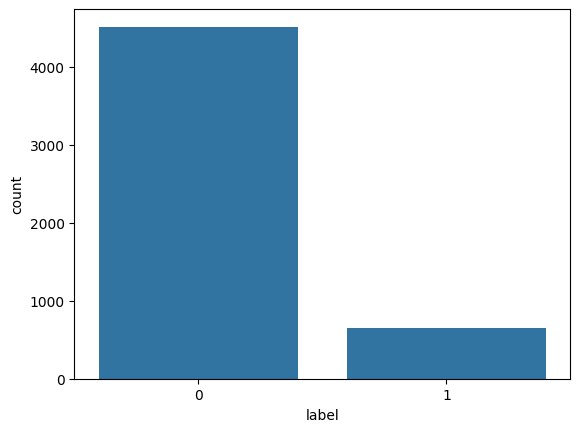

In [ ]:
import seaborn as sns
sns.countplot(x='label', data=df)

In [ ]:
df['length'] = df['message'].apply(len)

In [ ]:
df.groupby('label')['length'].mean()

,length
label,
0,70.459256
1,137.891271


<Axes: >

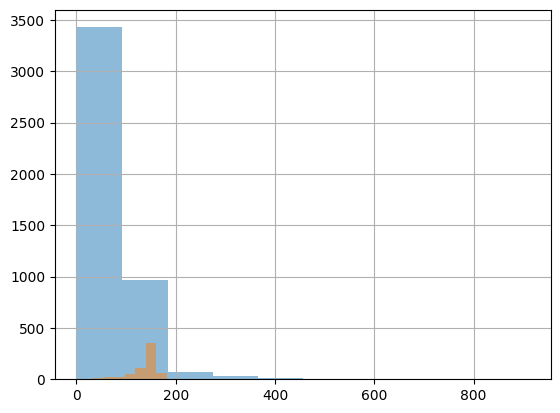

In [ ]:
import matplotlib.pyplot as plt

df[df['label']==0]['length'].hist(alpha=0.5)
df[df['label']==1]['length'].hist(alpha=0.5)

In [ ]:
from collections import Counter

words = Counter(" ".join(df['message']).split())
words.most_common(10)

[('to', 1972),
 ('you', 1562),
 ('I', 1375),
 ('a', 1198),
 ('the', 1114),
 ('and', 814),
 ('in', 731),
 ('i', 720),
 ('is', 691),
 ('u', 614)]

In [ ]:
spam_words = Counter(" ".join(df[df['label']==1]['message']).split())
spam_words.most_common(20)

[('to', 522),
 ('a', 314),
 ('your', 171),
 ('call', 163),
 ('the', 160),
 ('or', 155),
 ('for', 152),
 ('2', 151),
 ('you', 150),
 ('is', 130),
 ('Call', 116),
 ('on', 112),
 ('have', 110),
 ('from', 109),
 ('and', 102),
 ('&', 89),
 ('with', 86),
 ('ur', 86),
 ('of', 79),
 ('FREE', 75)]

In [ ]:
def preprocess(text):
    text = text.lower()
    return text

In [ ]:
df['cleaned_message'] = df['message'].apply(preprocess)

In [ ]:
def preprocess(text):
   text=text.split()
   return text


In [ ]:
import re
def preprocess(text):
 text = re.sub(r'[^a-zA-Z]', ' ', text)
 return text


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [ ]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
def preprocess(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [ps.stem(word) for word in words]

    return " ".join(words)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X = cv.fit_transform(df['cleaned_message'])

In [ ]:
print(X.shape)

(5169, 8672)


In [ ]:
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9738878143133463

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[904,  11],
       [ 16, 103]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       915
           1       0.90      0.87      0.88       119

    accuracy                           0.97      1034
   macro avg       0.94      0.93      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X=tfidf.fit_transform(df['cleaned_message'])

In [ ]:
y=df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# NEW model train
model = MultinomialNB()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# accuracy
accuracy_score(y_test, y_pred)

0.9448742746615088

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       897
           1       1.00      0.58      0.74       137

    accuracy                           0.94      1034
   macro avg       0.97      0.79      0.85      1034
weighted avg       0.95      0.94      0.94      1034



In [41]:
TfidfVectorizer(ngram_range=(1,2),
                max_features=3000)

TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

In [42]:
X = tfidf.fit_transform(df['cleaned_message'])

In [44]:
y = df['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# accuracy
accuracy_score(y_test, y_pred)

0.960348162475822

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       907
           1       1.00      0.68      0.81       127

    accuracy                           0.96      1034
   macro avg       0.98      0.84      0.89      1034
weighted avg       0.96      0.96      0.96      1034

